# Normalizing Data Practice

This is my own practice notebook based on what I learned in the IBM Data Analyst Capstone Project on Coursera.

The goal is to practice checking data quality and normalizing yearly compensation values.

## 1. Import libraries

`pandas` is used for working with table data.

`matplotlib` is used for creating charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the dataset

The CSV file is loaded into a pandas DataFrame called `df`.

In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## 3. Check and remove duplicate rows

Duplicate rows can make analysis inaccurate because the same response may be counted more than once.

In [3]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows before removal:", duplicate_count)

df = df.drop_duplicates().copy()

duplicate_count_after = df.duplicated().sum()
print("Duplicate rows after removal:", duplicate_count_after)

Duplicate rows before removal: 0
Duplicate rows after removal: 0


## 4. Check missing values in `CodingActivities`

Missing values should be checked before using a column in analysis.

In [4]:
missing_before = df["CodingActivities"].isna().sum()
print("Missing CodingActivities values before filling:", missing_before)

Missing CodingActivities values before filling: 10971


## 5. Fill missing `CodingActivities` values

Forward-fill copies the previous available value into the missing row.

This is only a practice shortcut. In a real analysis, the best method depends on the meaning of the data.

In [5]:
df["CodingActivities"] = df["CodingActivities"].ffill()

missing_after = df["CodingActivities"].isna().sum()
print("Missing CodingActivities values after filling:", missing_after)

Missing CodingActivities values after filling: 0


## 6. Identify compensation-related columns

This checks which columns appear to be related to compensation.

In [6]:
compensation_columns = [col for col in df.columns if "comp" in col.lower()]
print("Compensation-related columns:")
print(compensation_columns)

Compensation-related columns:
['CompTotal', 'AIComplex', 'ConvertedCompYearly']


## 7. Create a clean salary dataset for normalization

`ConvertedCompYearly` is the yearly compensation column.

Rows with missing, zero, or negative salary values are removed from the salary-only copy.

The original `df` is not changed.

In [7]:
salary_col = "ConvertedCompYearly"

salary_df = df[[salary_col]].dropna().copy()
salary_df = salary_df[salary_df[salary_col] > 0].copy()

print("Valid salary rows:", len(salary_df))
salary_df.head()

Valid salary rows: 23435


,ConvertedCompYearly
72,7322.0
374,30074.0
379,91295.0
385,53703.0
389,110000.0


## 8. Apply Min-Max normalization

Min-Max normalization converts salary values into a 0 to 1 scale.

- 0 means the lowest salary in this data
- 1 means the highest salary in this data
- values between 0 and 1 show the position between lowest and highest

In [8]:
min_value = salary_df[salary_col].min()
max_value = salary_df[salary_col].max()

salary_df["ConvertedCompYearly_MinMax"] = (
    (salary_df[salary_col] - min_value) / (max_value - min_value)
)

salary_df[[salary_col, "ConvertedCompYearly_MinMax"]].head()

,ConvertedCompYearly,ConvertedCompYearly_MinMax
72,7322.0,0.000450
374,30074.0,0.001850
379,91295.0,0.005616
385,53703.0,0.003303
389,110000.0,0.006766


## 9. Apply Z-score normalization

Z-score normalization compares each salary to the average salary.

- 0 means around the average
- positive values are above average
- negative values are below average

In [9]:
mean_value = salary_df[salary_col].mean()
std_value = salary_df[salary_col].std()

salary_df["ConvertedCompYearly_Zscore"] = (
    (salary_df[salary_col] - mean_value) / std_value
)

salary_df[[salary_col, "ConvertedCompYearly_Zscore"]].head()

,ConvertedCompYearly,ConvertedCompYearly_Zscore
72,7322.0,-0.422117
374,30074.0,-0.300290
379,91295.0,0.027521
385,53703.0,-0.173767
389,110000.0,0.127678


## 10. Visualize normalized data clearly

The full salary column has extreme outliers, so the first chart can look crushed and unreadable.

For visualization only, this step removes the extreme top 1% salary values in a separate plotting copy.

The original dataset is not changed.

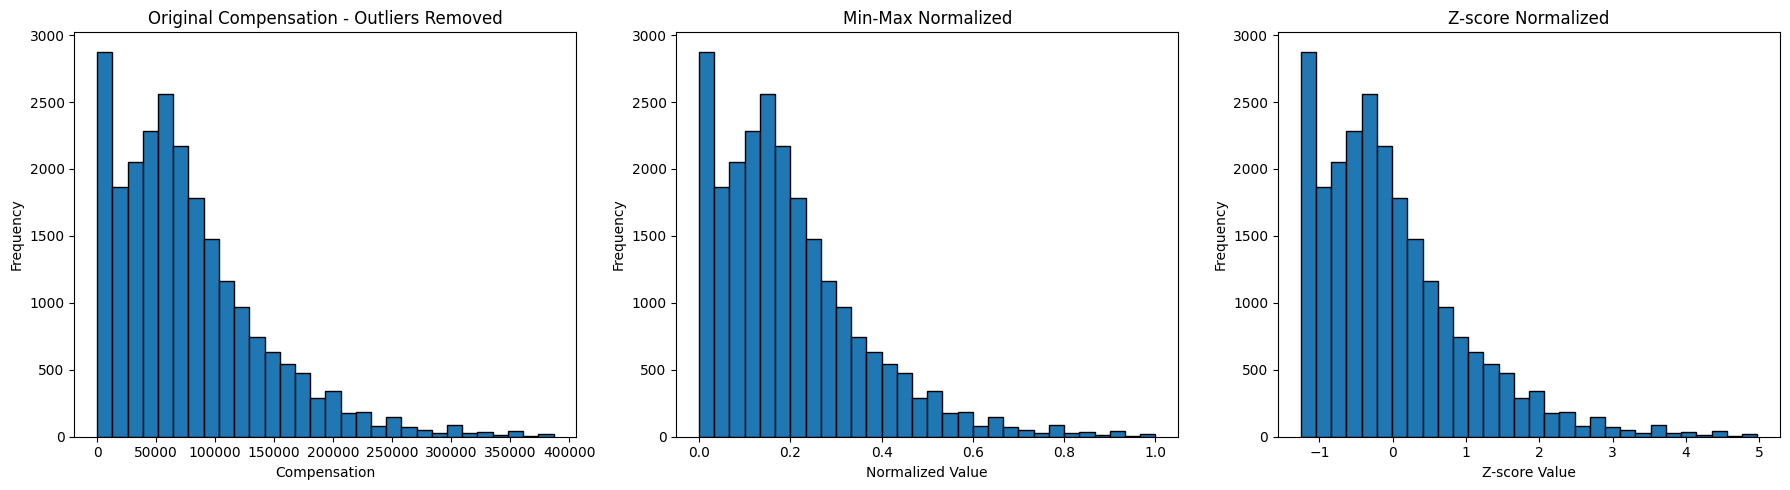

In [10]:
# Create a separate copy only for visualization
plot_df = salary_df[[salary_col]].copy()

# Remove the extreme top 1% salary values only for clearer charts
upper_limit = plot_df[salary_col].quantile(0.99)
plot_df = plot_df[plot_df[salary_col] <= upper_limit].copy()

# Recalculate Min-Max normalization for the plotting copy
plot_min = plot_df[salary_col].min()
plot_max = plot_df[salary_col].max()

plot_df["ConvertedCompYearly_MinMax"] = (
    (plot_df[salary_col] - plot_min) / (plot_max - plot_min)
)

# Recalculate Z-score normalization for the plotting copy
plot_mean = plot_df[salary_col].mean()
plot_std = plot_df[salary_col].std()

plot_df["ConvertedCompYearly_Zscore"] = (
    (plot_df[salary_col] - plot_mean) / plot_std
)

# Create three histograms side by side
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(plot_df[salary_col], bins=30, edgecolor="black")
plt.title("Original Compensation - Outliers Removed")
plt.xlabel("Compensation")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(plot_df["ConvertedCompYearly_MinMax"], bins=30, edgecolor="black")
plt.title("Min-Max Normalized")
plt.xlabel("Normalized Value")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.hist(plot_df["ConvertedCompYearly_Zscore"], bins=30, edgecolor="black")
plt.title("Z-score Normalized")
plt.xlabel("Z-score Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 11. Quick checks

These checks confirm that the normalized columns were created correctly.

In [11]:
print("Min-Max minimum:", plot_df["ConvertedCompYearly_MinMax"].min())
print("Min-Max maximum:", plot_df["ConvertedCompYearly_MinMax"].max())
print("Z-score mean:", round(plot_df["ConvertedCompYearly_Zscore"].mean(), 4))
print("Z-score standard deviation:", round(plot_df["ConvertedCompYearly_Zscore"].std(), 4))

Min-Max minimum: 0.0
Min-Max maximum: 1.0
Z-score mean: 0.0
Z-score standard deviation: 1.0


## Summary

In this practice notebook, I checked duplicates, handled missing values, normalized yearly compensation data using Min-Max and Z-score methods, and created clearer charts by removing extreme salary outliers only from the visualization copy.